# Energy-gap law con las tasas de Anderson (2013)

1. Tomo los $k_{NR}$ de `AndersonModel` (medidos a $T_0$) y los llevo a $T = 0$:
   $k_{NR}(0) = k_{NR}(T_0)\,/\,[1 + n(T_0)]^p$, con $p = \Delta E / \hbar\omega$.
2. Ajusto $k_{NR}(0) = B\,e^{-a\Delta E}$.
3. Heatmap de la tasa estimada $\log_{10}[B\,e^{-a\Delta E}\,F(T)]$ para todos los pares de niveles, con $F_\downarrow = [1+n(T)]^p$ y $F_\uparrow = n(T)^p$.

Anderson no reporta $\hbar\omega$ ni $T_0$; uso los mismos valores que `AndersonModelUnfolded`.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from jablonski import SingletState
from jablonski.transitions import InternalConversion

from upconversion_models.anderson import AndersonModel
from upconversion_models.utils import hc, k

T0 = 293.15  # K
PHONON = 350  # cm⁻¹

pd.set_option("display.float_format", "{:.3g}".format)

model = AndersonModel()
kB = (k / hc).to("1/cm/K").magnitude  # cm⁻¹/K


def wavenumber(state):
    # AndersonModel escribe las energías como cm⁻¹ · energy_factor
    return (state.energy / AndersonModel.energy_factor).to("").magnitude


def occupation(T):
    return 1 / np.expm1(PHONON / (kB * T))

## 1. Tasas no radiativas

`dE` en cm⁻¹, `k` = $k_{NR}(T_0)$ y `k_0` = $k_{NR}(0)$ en s⁻¹.

In [2]:
er_transitions = [t for t in model._yield(InternalConversion) if str(t.high).startswith("Er")]

df = pd.DataFrame(
    {
        "transición": [f"{t.high}→{t.low}" for t in er_transitions],
        "dE": [round(wavenumber(t.high) - wavenumber(t.low)) for t in er_transitions],
        "k": [t.rate.default.to("1/s").magnitude for t in er_transitions],
    }
).set_index("transición")

df["p"] = df["dE"] / PHONON
df["k_0"] = df["k"] / (1 + occupation(T0)) ** df["p"]

df

,dE,k,p,k_0
transición,,,,
Er9→Er8,1600,1.76e+06,4.57,7.13e+05
Er8→Er7,4000,4.34e+04,11.4,4.53e+03
Er7→Er6,2200,1e+06,6.29,2.88e+05
Er6→Er5,3300,26,9.43,4.03
Er5→Er4,2500,0,7.14,0
Er4→Er3,2300,2.21e+04,6.57,6.03e+03
Er3→Er2,3700,61,10.6,7.54


## 2. Ajuste exponencial

Quedan fuera del ajuste las transiciones en `EXCLUDE` y las que tienen $k = 0$ (Er5→Er4).

In [3]:
EXCLUDE = {"Er8→Er7", "Er6→Er5", "Er7→Er6"}

used = (df["k_0"] > 0) & ~df.index.isin(list(EXCLUDE))
fit = df[used]
slope, intercept = np.polyfit(fit["dE"], np.log(fit["k_0"]), 1)
a, B = -slope, np.exp(intercept)

print(f"a = {a:.3e} cm")
print(f"B = {B:.3e} s⁻¹")

a = 5.358e-03 cm
B = 2.505e+09 s⁻¹


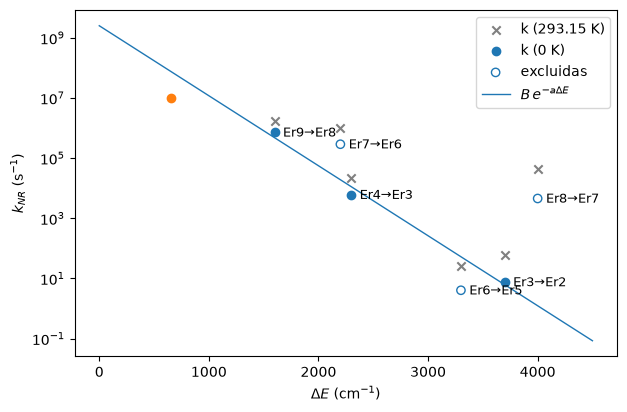

In [12]:
fig, ax = plt.subplots(figsize=(7, 4.5))

points = df[df["k_0"] > 0]
excluded = df[(df["k_0"] > 0) & ~used]

ax.scatter(points["dE"], points["k"], marker="x", c="gray", label=f"k ({T0} K)")
ax.scatter(fit["dE"], fit["k_0"], zorder=3, label="k (0 K)")
if len(excluded):
    ax.scatter(excluded["dE"], excluded["k_0"], zorder=3, fc="none", ec="C0", label="excluidas")
for name, row in points.iterrows():
    ax.annotate(name, (row["dE"], row["k_0"]), xytext=(6, -3), textcoords="offset points", fontsize=9)

dE = np.linspace(0, 4500, 100)
ax.plot(dE, B * np.exp(-a * dE), c="C0", lw=1, label=r"$B\,e^{-a\Delta E}$")

ax.set(yscale="log", xlabel=r"$\Delta E$ (cm$^{-1}$)", ylabel=r"$k_{NR}$ (s$^{-1}$)")
ax.legend()

plt.scatter(650, (10) * 1e6)
plt.show()

In [5]:
residuals = np.log10(points["k_0"] / (B * np.exp(-a * points["dE"])))
pd.DataFrame({"log10(k_0 / ajuste)": residuals.round(2), "en ajuste": used[points.index]})

,log10(k_0 / ajuste),en ajuste
transición,,
Er9→Er8,0.18,True
Er8→Er7,3.57,False
Er7→Er6,1.18,False
Er6→Er5,-1.11,False
Er4→Er3,-0.27,True
Er3→Er2,0.09,True


## 3. Heatmap de la tasa estimada $k(T) = B\,e^{-a\Delta E}\,F(T)$

Fila = origen, columna = destino. Debajo de la diagonal: relajación; arriba: excitación térmica.
Cada celda muestra $\log_{10} k$ con $k$ en s⁻¹ (p.ej. 3 → $10^3$ s⁻¹).
En **negrita**: transiciones usadas en el ajuste; en *itálica*: están en el modelo pero quedaron fuera del ajuste.

In [6]:
levels = sorted(
    {str(s): s for s in model._yield(SingletState) if str(s).startswith("Er")}.values(),
    key=wavenumber,
)
labels = [str(s) for s in levels]
E = np.array([wavenumber(s) for s in levels])
in_fit = set(fit.index)
in_model = set(df.index)


def log_rate(T):
    # log10[B e^{-aΔE} F(T)], calculado en log para no tener underflow
    n = occupation(T)
    dE = E[:, None] - E[None, :]  # from (fila) − to (columna)
    p = np.abs(dE) / PHONON
    log_F = p * np.log10(np.where(dE > 0, 1 + n, n))
    L = np.log10(B) - a * np.abs(dE) * np.log10(np.e) + log_F
    np.fill_diagonal(L, np.nan)
    return L


def plot_heatmap(T, vmin=-10):
    L = log_rate(T)
    vmax = np.nanmax(L)
    plt.figure(figsize=(7, 6))
    im = plt.imshow(L, vmin=vmin, vmax=vmax, cmap="viridis")
    plt.colorbar(im, extend="min", label=r"$\log_{10}\,k$ (s$^{-1}$)")

    for i, j in np.ndindex(L.shape):
        if np.isnan(L[i, j]):
            continue
        name = f"{labels[i]}→{labels[j]}"
        plt.text(
            j, i, f"{L[i, j]:.3}", ha="center", va="center", fontsize=9,
            color="black" if L[i, j] > (vmin + vmax) / 2 else "white",
            fontweight="bold" if name in in_fit else "normal",
            fontstyle="italic" if name in in_model - in_fit else "normal",
        )

    plt.xticks(range(len(labels)), labels)
    plt.yticks(range(len(labels)), labels)
    plt.xlabel("to")
    plt.ylabel("from")
    plt.title(rf"$\log_{{10}} k(T) $, T = {T} K")
    plt.show()

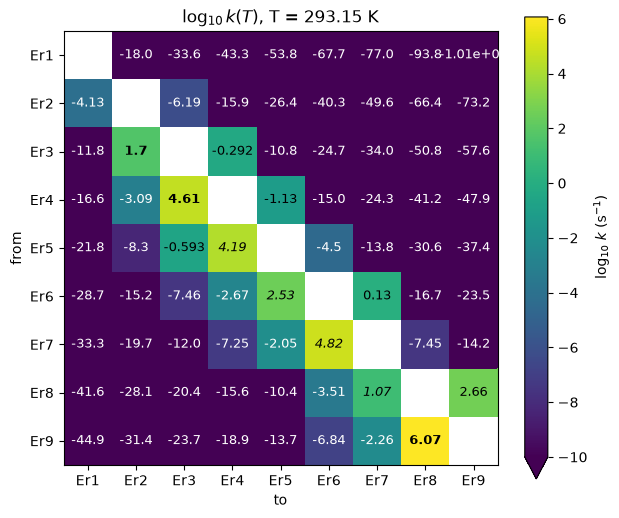

In [7]:
plot_heatmap(T0)

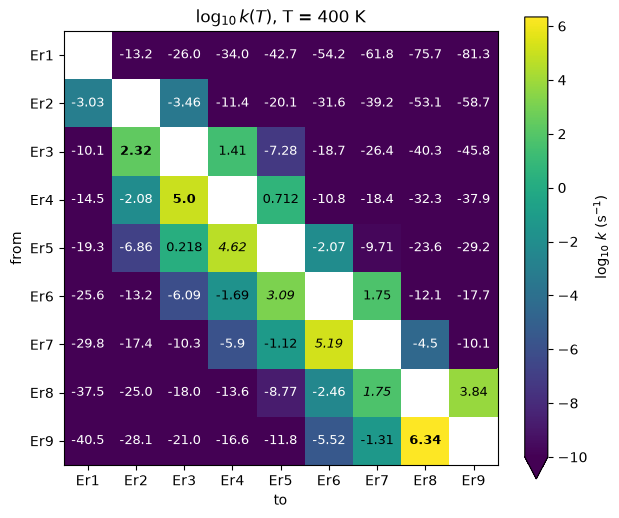

In [8]:
plot_heatmap(400)

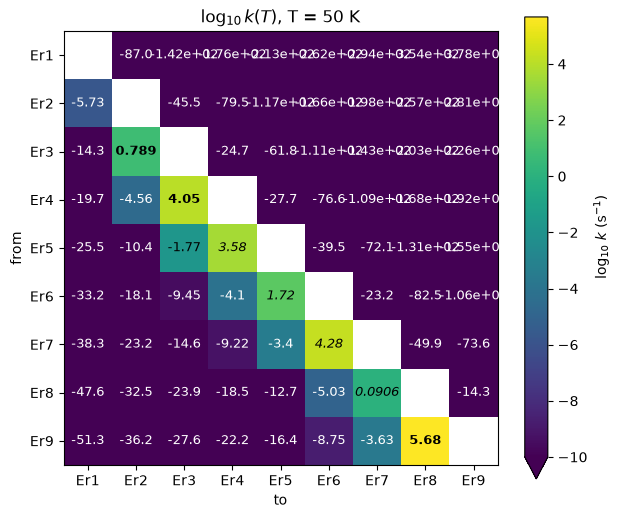

In [9]:
plot_heatmap(50)